# From Stochastic Simulation to Market-Based Execution
### Adrián Vázquez
---

## Notebooks

### Real Data Execution Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ADRIANVM117/data-science-portfolio/blob/main/Optimal_execution_under_market_impact/notebooks/03_real_data_execution_analysis.ipynb)


[Open in Colab](https://colab.research.google.com/github/ADRIANVM117/data-science-portfolio/blob/main/Optimal_execution_under_market_impact/notebooks/03_real_data_execution_analysis.ipynb)

## Objective

In the previous stage, execution strategies were evaluated under simulated price dynamics using an Arithmetic Brownian Motion.

In this notebook, we transition to a **market-based setting**, where execution is evaluated using **real intraday price and volume data**.

The objective is to assess how theoretical execution models behave when exposed to actual market conditions.

---

## Framework

We consider a discrete execution problem over a fixed horizon:

- Total shares to execute: $Q$
- Time horizon divided into $N$ intervals of length $\tau = T/N$
- Execution schedule: $\{n_k\}_{k=1}^{N}$

Using real market data:

- $S_k$ = observed mid price at time $k$
- $V_k$ = observed market volume at time $k$

Execution prices incorporate market impact:

$$
P_k = S_k + \gamma \sum_{j<k} n_j + \eta \frac{n_k}{\tau}
$$

---

## What Changes from the Simulation?

Previously:

$$
S_{k+1} = S_k + \sigma \sqrt{\tau} \epsilon_k
$$

Now:

- $S_k$ is directly observed from the market
- Volatility $\sigma$ is estimated from real returns:
  
$$
\hat{\sigma} = \text{std}(\log(S_{k+1}/S_k))
$$

- VWAP schedules are constructed from real volume:

$$
w_k = \frac{V_k}{\sum_{i=1}^{N} V_i}
$$

---

## Research Questions

This notebook aims to answer the following:

### 1. How do execution strategies behave under real market dynamics?

- Does TWAP remain a strong baseline?
- Does VWAP improve when using real volume profiles?

---

### 2. How does real volatility affect execution risk?

- Is the variance of implementation shortfall higher or lower than in simulations?
- Do real price paths exhibit heavier tails?

---

### 3. How does market impact interact with real price movements?

- Does impact dominate execution cost?
- Or do price trends play a larger role?

---

### 4. Which strategy performs better under real data?

We compare:

- **TWAP**
- **VWAP (real volume-based)**
- **Almgren–Chriss**

Using:

- Implementation Shortfall:
  
$$
\text{IS} = \sum_{k=1}^{N} n_k P_k - Q S_0
$$

- Expected Cost
- Execution Risk (standard deviation)

---

### 5. Does the cost-risk trade-off persist in real markets?

- Can we still observe a clear frontier when varying $\lambda$?
- Is the optimal region stable under real data?

---

## Expected Contribution

This notebook bridges the gap between:

- **Theoretical execution models**
- **Real-world trading environments**

By doing so, it allows us to evaluate whether:

> Optimal execution frameworks such as Almgren–Chriss remain effective when applied to real market data.



In [2]:
# libs
import plotly.io as pio
#pio.renderers.default = "notebook_connected+png" 

from IPython.display import Image, display
import sys
import os
# Add project root to path
sys.path.append(os.path.abspath(".."))

# libs 
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.models.twap import twap_schedule
from src.models.vwap import generate_vwap_schedule
from src.models.inventory_from_schedule import inventory_from_schedule
from src.models.almgren_chriss_shedule import almgren_chriss_schedule
from src.analytics.implementation_shortfall import implementation_shortfall
from src.analytics.get_intraday_prices import get_intraday_prices
from src.models.simulate_brownian_motion_price_path import simulate_brownian_price_path, simulate_multiple_price_paths, simulate_execution_prices
from src.models.volume_aware_ac_schedule import volume_aware_ac_schedule

## 1. Real Intraday Market Data

In this section, we introduce the real market dataset used for the execution analysis.

We work with intraday data for the asset:

- Symbol: $\text{SPY}$
- Frequency: $5$-minute intervals
- Variables: $\{\text{Open}, \text{High}, \text{Low}, \text{Close}, \text{Volume}\}$

Let:

$$
S_k = \text{Close price at time } k
$$

This will serve as the **observable mid-price proxy** used in the execution framework.

---

### 1.1 Data Structure

The dataset is indexed by timestamps:

$$
t_k \in \{t_0, t_1, \dots, t_N\}
$$

with constant spacing:

$$
\tau = 5 \text{ minutes}
$$

Each observation corresponds to:

- Price dynamics through $S_k$
- Market activity through traded volume $V_k$

---

### 1.2 Interpretation for Execution

In contrast to the simulated framework:

$$
S_{k+1} = S_k + \sigma \sqrt{\tau} \epsilon_k
$$

we now use:

$$
S_k = \text{observed market price}
$$

This introduces key differences:

- Price paths are no longer Gaussian
- Volatility is time-varying
- Trends and microstructure effects may appear

---

### 1.3 Role of Volume

Volume plays a central role in execution, particularly for VWAP:

$$
w_k = \frac{V_k}{\sum_{i=1}^{N} V_i}
$$

where:

- $V_k$ = traded volume at time $k$
- $w_k$ = execution weight for VWAP

This allows us to construct **data-driven execution schedules**, rather than assuming stylized volume profiles.

---

### 1.4 Objective of This Section

The goal is to prepare the dataset for execution analysis by:

- Defining the price process $S_k$
- Defining the volume process $V_k$
- Establishing the time grid $\{t_k\}$

These elements will be used to simulate execution under real market conditions in the following sections.

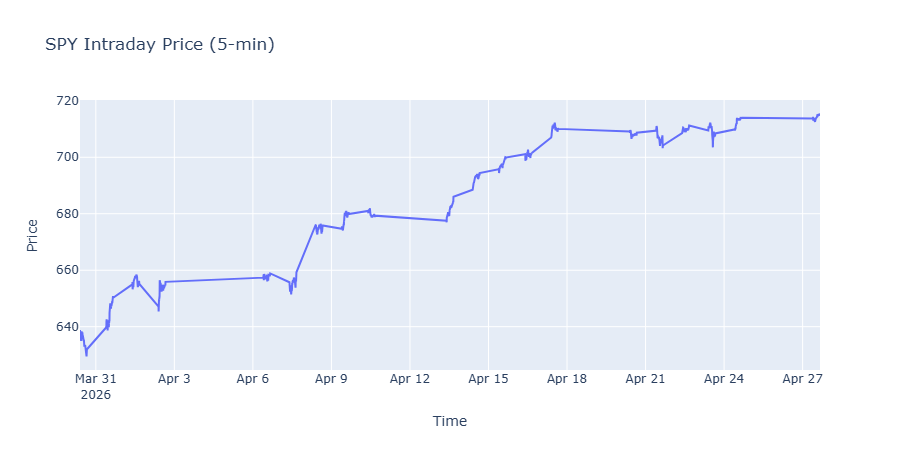

In [ ]:
import plotly.graph_objects as go

API_KEY = #"YOUR_APIKEY"

df_spy_5min = get_intraday_prices(
    symbol="SPY",
    api_key=API_KEY,
    interval="5min",
    outputsize="full",
    extended_hours="false"
)

# plot 
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_spy_5min.index,
        y=df_spy_5min["Close"],
        mode="lines",
        name="SPY Close Price"
    )
)

fig.update_layout(
    title="SPY Intraday Price (5-min)",
    xaxis_title="Time",
    yaxis_title="Price",
    height=450,
    width=900
)

fig.show()
fig.write_image("../results/plots/spy_intraday_price_5_min.png")
display(Image(filename="../results/plots/spy_intraday_price_5_min.png"))

## 2. Data Preparation

In this section, we transform raw intraday market data into a format suitable for execution analysis.

We focus on extracting three key components:

- Returns (for volatility estimation)
- Volatility ($\sigma$)
- Volume profile (for VWAP construction)

---

### 2.1 Returns and Volatility

We define log-returns as:

$$
r_k = \log\left(\frac{S_{k}}{S_{k-1}}\right)
$$

Volatility is estimated as:

$$
\hat{\sigma} = \text{std}(r_k)
$$

This provides a data-driven estimate of market uncertainty.

---

### 2.2 Time Grid

The execution horizon is defined over:

$$
t_k = t_0 + k \tau
$$

where:

- $\tau = 5$ minutes
- $k = 0, \dots, N$

---

### 2.3 Volume Profile

We construct the empirical volume profile:

$$
w_k = \frac{V_k}{\sum_{i=1}^{N} V_i}
$$

This allows VWAP execution to be aligned with actual market liquidity.

---

### 2.4 Objective

The goal of this section is to obtain:

- Clean price series $S_k$
- Volatility estimate $\hat{\sigma}$
- Volume weights $w_k$

These will be used to simulate execution strategies under real market conditions.

In [5]:
df = df_spy_5min.copy()
# Log returns
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
# Drop first NaN
df = df.dropna()
# Volatility estimate
sigma_hat = df["log_return"].std()
print(f"Estimated volatility (sigma): {sigma_hat:.6f}")

# Volume profile
volume = df["Volume"].values
volume_weights = volume / volume.sum()
# check
print(f"Sum of weights: {volume_weights.sum():.4f}")

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=volume_weights,
        mode="lines",
        name="Volume Weights"
    )
)

fig.update_layout(
    title="Empirical Volume Profile",
    xaxis_title="Time",
    yaxis_title="Weight",
    height=400,
    width=900
)

fig.show()

Estimated volatility (sigma): 0.001122
Sum of weights: 1.0000


## 3. Execution under Real Market Data

In this section, we apply execution strategies to real intraday market data.

We evaluate how deterministic execution schedules behave when exposed to:
- Real price dynamics $S_k$
- Empirical volume profile $V_k$
- Market impact effects

---

### 3.1 Execution Framework

We consider a discrete execution problem:

- Total shares to execute: $Q$
- Time horizon divided into $N$ intervals
- Execution schedule: $\{n_k\}_{k=1}^{N}$

The inventory evolves as:

$$
x_k = Q - \sum_{j=1}^{k} n_j
$$

where $x_k$ represents the remaining shares after $k$ executions.

In our implementation, the inventory path is constructed directly from the execution schedule. 
---

### 3.2 Execution Price with Market Impact

Execution prices are modeled as:

$$
P_k = S_k + \gamma \sum_{j<k} n_j + \eta \frac{n_k}{\tau}
$$

Where:

- $S_k$ = observed market price
- $\gamma$ = permanent impact
- $\eta$ = temporary impact
- $n_k$ = shares executed at time $k$

This formulation captures:

- Accumulated impact from previous trades
- Instantaneous cost of aggressive execution

Execution prices are computed directly using this framework. 

---

### 3.3 Execution Strategies

We evaluate three strategies:

#### TWAP

Uniform execution:

$$
n_k = \frac{Q}{N}
$$

This strategy distributes trades evenly over time. 

---

#### VWAP (Data-Driven)

Execution is proportional to observed volume:

$$
n_k = Q \cdot \frac{V_k}{\sum_{i=1}^{N} V_i}
$$

This aligns execution with market liquidity. 

---

#### Almgren–Chriss

Optimal execution balancing cost and risk:

$$
\ddot{x}(t) = \kappa^2 x(t)
$$

with solution:

$$
x(t) = Q \frac{\sinh(\kappa (T - t))}{\sinh(\kappa T)}
$$

where:

$$
\kappa = \sqrt{\frac{\lambda \sigma^2}{\eta}}
$$

This allows dynamic adjustment of execution speed based on risk aversion.

---

### 3.4 Implementation Shortfall

Execution performance is evaluated using:

$$
\text{IS} = \sum_{k=1}^{N} n_k (P_k - S_0)
$$

Where:

- $S_0$ = initial price

This metric captures the total cost of execution relative to a benchmark.

The implementation is computed directly from execution prices and schedules. 

---

### 3.5 Objective of This Section

The goal is to:

- Apply execution strategies to real price data
- Incorporate market impact into execution prices
- Compute execution cost using implementation shortfall

This provides a direct comparison between:

- Theoretical execution behavior
- Real-world execution outcomes

---

### 3.6 Expected Insights

By applying these strategies to real data, we expect to observe:

- Deviations from simulated behavior
- Increased variability in execution cost
- Sensitivity of strategies to real volume patterns

This sets the stage for Monte Carlo evaluation and cost–risk analysis in the following sections.

In [6]:
# 3. Execution under real market data

# Base execution parameters
Q = 50_000
lambda_risk = 1e-5
gamma = 1e-6
eta = 1e-4

# Use real data
df_exec = df.copy()

# Price process
mid_prices = df_exec["Close"].values

# For N trades, we need N+1 prices
N = len(mid_prices) - 1
T = 1.0
tau = T / N

# Use first N volume observations for execution schedule
volume_profile = df_exec["Volume"].values[:N]

# Price volatility in price units for Almgren-Chriss
sigma_price = np.diff(mid_prices).std()

print(f"N: {N}")
print(f"tau: {tau:.6f}")
print(f"sigma_price: {sigma_price:.6f}")
#-----------------------------------------------

# Generate schedules

twap = twap_schedule(Q, T, N)

vwap_shares = generate_vwap_schedule(
    total_shares=Q,
    volume_profile=volume_profile
)

vwap_inventory = inventory_from_schedule(Q, vwap_shares)

ac = almgren_chriss_schedule(
    Q=Q,
    T=T,
    N=N,
    sigma=sigma_price,
    eta=eta,
    lambda_risk=lambda_risk
)

schedules = {
    "TWAP": twap["shares_per_slice"],
    "VWAP": vwap_shares,
    "Almgren-Chriss": ac["shares_per_slice"]
}

inventory_paths = {
    "TWAP": twap["inventory_path"],
    "VWAP": vwap_inventory,
    "Almgren-Chriss": ac["inventory_path"]
}

# check
for name, schedule in schedules.items():
    print(f"{name}: total shares = {schedule.sum():,.0f}")

# Compute execution prices and IS for each strategy

execution_results = {}
is_results = {}

for name, schedule in schedules.items():

    exec_result = simulate_execution_prices(
        mid_prices=mid_prices,
        shares_per_slice=schedule,
        gamma=gamma,
        eta=eta,
        tau=tau
    )

    is_result = implementation_shortfall(
        execution_prices=exec_result["execution_prices"],
        shares_per_slice=schedule,
        S0=mid_prices[0]
    )

    execution_results[name] = exec_result
    is_results[name] = is_result

summary_real = pd.DataFrame(is_results).T
summary_real

N: 1558
tau: 0.000642
sigma_price: 0.748508
TWAP: total shares = 50,000
VWAP: total shares = 50,000
Almgren-Chriss: total shares = 50,000


,total_cost,avg_price,is_per_share
TWAP,2.549146e+06,688.932918,50.982918
VWAP,2.433951e+06,686.629016,48.679016
Almgren-Chriss,2.538870e+06,688.727408,50.777408


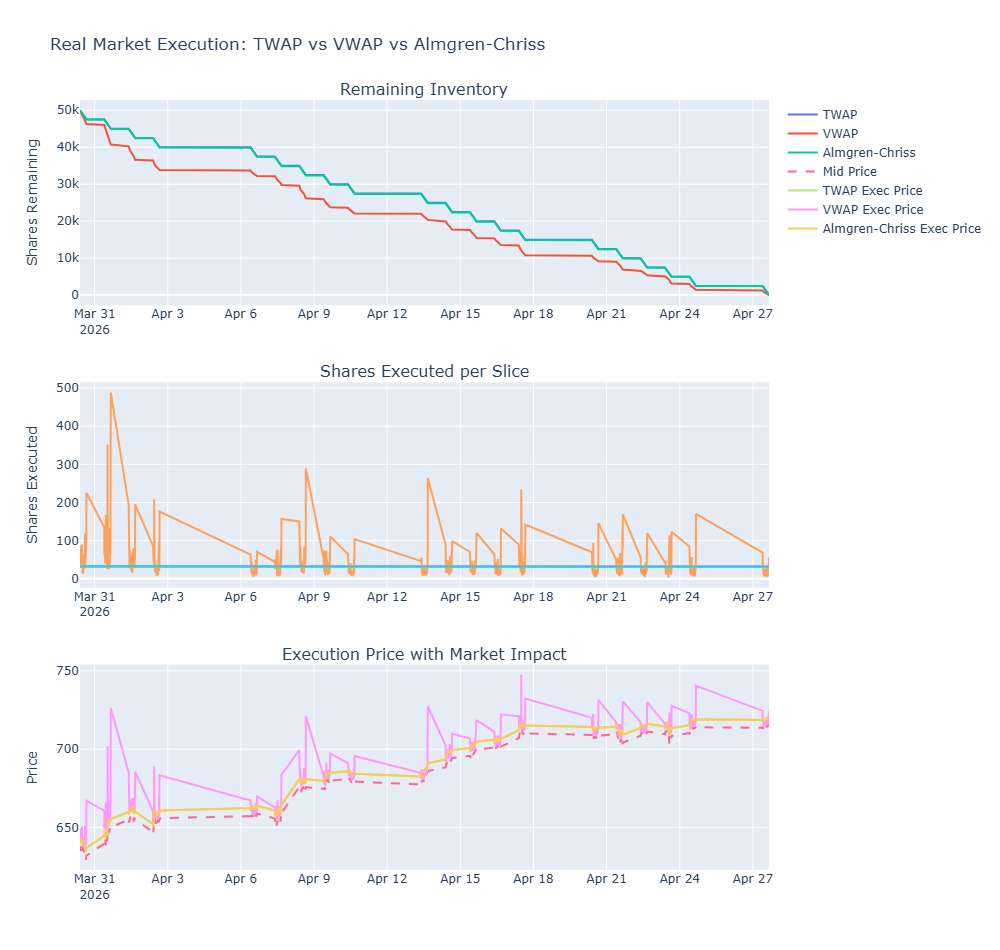

In [7]:
# Comparative figure: inventory, shares per slice, execution prices

time_inventory = df_exec.index[:N+1]
time_execution = df_exec.index[:N]

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=False,
    vertical_spacing=0.10,
    subplot_titles=[
        "Remaining Inventory",
        "Shares Executed per Slice",
        "Execution Price with Market Impact"
    ]
)

# 1. Inventory paths
for name, inventory in inventory_paths.items():
    fig.add_trace(
        go.Scatter(
            x=time_inventory,
            y=inventory,
            mode="lines",
            name=name
        ),
        row=1,
        col=1
    )

# 2. Shares per slice
for name, schedule in schedules.items():
    fig.add_trace(
        go.Scatter(
            x=time_execution,
            y=schedule,
            mode="lines",
            name=f"{name} shares",
            showlegend=False
        ),
        row=2,
        col=1
    )

# 3. Execution prices
fig.add_trace(
    go.Scatter(
        x=time_execution,
        y=mid_prices[:-1],
        mode="lines",
        name="Mid Price",
        line=dict(dash="dash")
    ),
    row=3,
    col=1
)

for name, result in execution_results.items():
    fig.add_trace(
        go.Scatter(
            x=time_execution,
            y=result["execution_prices"],
            mode="lines",
            name=f"{name} Exec Price"
        ),
        row=3,
        col=1
    )

fig.update_layout(
    title="Real Market Execution: TWAP vs VWAP vs Almgren-Chriss",
    height=950,
    width=1000
)

fig.update_yaxes(title_text="Shares Remaining", row=1, col=1)
fig.update_yaxes(title_text="Shares Executed", row=2, col=1)
fig.update_yaxes(title_text="Price", row=3, col=1)

fig.show()
fig.write_image("../results/plots/real_market_execution_twap_vs_vwap_vs_almgren-chriss.png")
display(Image(filename="../results/plots/real_market_execution_twap_vs_vwap_vs_almgren-chriss.png"))

### Interpretation

The comparison reveals how execution strategies behave under real intraday market conditions.

- **VWAP achieves the lowest execution cost** in this scenario, with a lower average execution price and implementation shortfall.

- This is driven by its ability to **align trades with high-liquidity periods**, reducing temporary market impact.

- **TWAP and Almgren–Chriss exhibit similar performance**, both in total cost and execution price, indicating that under low risk aversion ($\lambda$ small), Almgren–Chriss behaves close to a linear execution schedule.

- The inventory paths confirm this:
  - TWAP decreases linearly
  - VWAP accelerates execution during high-volume periods
  - Almgren–Chriss shows a smoother, risk-aware trajectory

- The execution price plot highlights that:
  - All strategies experience **price impact above the mid price**
  - VWAP reduces extreme spikes by avoiding aggressive trades in low-liquidity intervals

---

### Key Insight

> Under real market conditions, liquidity timing becomes a dominant factor.

Even without optimizing explicitly for cost-risk trade-off, **VWAP can outperform optimal control strategies when volume information is informative and well exploited**.

---

### Critical Observation

This result suggests that:

- **Model-based optimal execution (Almgren–Chriss)** depends heavily on parameter calibration ($\lambda$, $\sigma$, $\eta$)
- **Data-driven strategies (VWAP)** can outperform when market microstructure is favorable

---

### Conclusion from Real Data

There is no universally optimal strategy:

- VWAP dominates when volume patterns are strong and predictable  
- Almgren–Chriss becomes more relevant when **risk control is critical**  
- TWAP remains a robust baseline but ignores both liquidity and risk  


### Lambda Calibration

We calibrate $\lambda$ by searching for the Almgren–Chriss schedule that minimizes execution risk while keeping expected cost close to the VWAP benchmark.

Formally:

$$
\lambda^* =
\arg\min_{\lambda} \text{Std}(Cost_\lambda)
$$

subject to:

$$
\mathbb{E}[Cost_\lambda] \leq \mathbb{E}[Cost_{VWAP}](1+\delta)
$$

where $\delta$ is a cost tolerance parameter.

This calibration reflects a practical execution objective:

> reduce risk without accepting excessive additional cost.

In [8]:
# Lambda calibration against VWAP benchmark

lambda_grid = np.logspace(-10, -2, 30)
delta = 0.02  # allow AC to be at most 2% more expensive than VWAP

benchmark_cost = is_results["VWAP"]["total_cost"]
cost_limit = benchmark_cost * (1 + delta)

calibration_results = []

for lam in lambda_grid:

    ac_candidate = almgren_chriss_schedule(
        Q=Q,
        T=T,
        N=N,
        sigma=sigma_price,
        eta=eta,
        lambda_risk=lam
    )

    schedule = ac_candidate["shares_per_slice"]

    exec_result = simulate_execution_prices(
        mid_prices=mid_prices,
        shares_per_slice=schedule,
        gamma=gamma,
        eta=eta,
        tau=tau
    )

    is_result = implementation_shortfall(
        execution_prices=exec_result["execution_prices"],
        shares_per_slice=schedule,
        S0=mid_prices[0]
    )

    total_cost = is_result["total_cost"]
    avg_price = is_result["avg_price"]
    is_per_share = is_result["is_per_share"]

    # Risk proxy: inventory exposure to price uncertainty
    inventory_path = ac_candidate["inventory_path"]
    timing_risk = sigma_price * np.sqrt(tau * np.sum(inventory_path[1:] ** 2))

    calibration_results.append({
        "lambda": lam,
        "kappa": ac_candidate["kappa"],
        "total_cost": total_cost,
        "avg_price": avg_price,
        "is_per_share": is_per_share,
        "timing_risk_proxy": timing_risk,
        "within_cost_limit": total_cost <= cost_limit
    })

calibration_df = pd.DataFrame(calibration_results)

feasible = calibration_df[calibration_df["within_cost_limit"]].copy()

if feasible.empty:
    print("No lambda satisfies the cost constraint. Increase delta.")
else:
    best_lambda_row = feasible.sort_values("timing_risk_proxy").iloc[0]
    best_lambda_row

In [9]:
calibration_df.head()


,lambda,kappa,total_cost,avg_price,is_per_share,timing_risk_proxy,within_cost_limit
0,1.000000e-10,0.000749,2.549146e+06,688.932916,50.982916,21597.168127,False
1,1.887392e-10,0.001028,2.549146e+06,688.932914,50.982914,21597.167410,False
2,3.562248e-10,0.001413,2.549146e+06,688.932911,50.982911,21597.166058,False
3,6.723358e-10,0.001941,2.549145e+06,688.932904,50.982904,21597.163505,False
4,1.268961e-09,0.002666,2.549145e+06,688.932892,50.982892,21597.158688,False


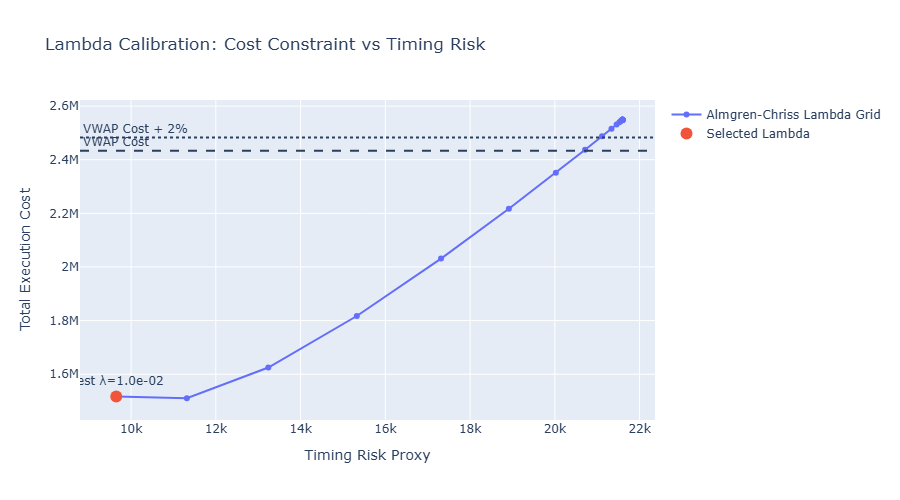

In [10]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=calibration_df["timing_risk_proxy"],
        y=calibration_df["total_cost"],
        mode="lines+markers",
        name="Almgren-Chriss Lambda Grid"
    )
)

fig.add_hline(
    y=benchmark_cost,
    line_dash="dash",
    annotation_text="VWAP Cost",
    annotation_position="top left"
)

fig.add_hline(
    y=cost_limit,
    line_dash="dot",
    annotation_text=f"VWAP Cost + {delta:.0%}",
    annotation_position="top left"
)

if not feasible.empty:
    fig.add_trace(
        go.Scatter(
            x=[best_lambda_row["timing_risk_proxy"]],
            y=[best_lambda_row["total_cost"]],
            mode="markers+text",
            text=[f"Best λ={best_lambda_row['lambda']:.1e}"],
            textposition="top center",
            name="Selected Lambda",
            marker=dict(size=12)
        )
    )

fig.update_layout(
    title="Lambda Calibration: Cost Constraint vs Timing Risk",
    xaxis_title="Timing Risk Proxy",
    yaxis_title="Total Execution Cost",
    height=500,
    width=900
)

fig.show()
fig.write_image("../results/plots/lambda_calibration__cost_constraint_vs_timing_risk.png")
display(Image(filename="../results/plots/lambda_calibration__cost_constraint_vs_timing_risk.png"))

### Interpretation

The calibration results show that no value of $\lambda$ satisfies the cost constraint relative to VWAP.

This indicates that, under the current setup:

- VWAP consistently achieves lower execution cost
- Almgren–Chriss cannot match VWAP cost within the specified tolerance

This is driven by the fact that:

- VWAP exploits real market liquidity through volume information
- Almgren–Chriss does not incorporate volume dynamics explicitly

As a result, liquidity-aware execution dominates model-based execution in this scenario.

---

### Key Insight

> Incorporating real market volume is more powerful than optimizing execution purely based on stochastic price dynamics.

---

### Implication

To make Almgren–Chriss competitive, it would be necessary to:

- incorporate volume information into the model
- calibrate impact parameters more accurately
- or increase the cost tolerance $\delta$

### Volume-Aware Almgren–Chriss Extension

The standard Almgren–Chriss schedule does not explicitly incorporate real market volume.

However, in real execution, liquidity is time-varying. Trading aggressively during low-volume periods increases temporary impact, while trading during high-volume periods may reduce execution cost.

To account for this, we construct a volume-aware Almgren–Chriss schedule by blending the original Almgren–Chriss trajectory with the empirical VWAP schedule:

$$
n_k^{VA-AC} = \alpha n_k^{AC} + (1-\alpha)n_k^{VWAP}
$$

where:

- $n_k^{AC}$ is the Almgren–Chriss schedule
- $n_k^{VWAP}$ is the real-volume VWAP schedule
- $\alpha \in [0,1]$ controls the weight assigned to the original Almgren–Chriss schedule

This extension preserves the risk-aware structure of Almgren–Chriss while incorporating observed market liquidity.

In [11]:
# asset diferent alpha´s

alpha_values = np.linspace(0, 1, 11)

va_results = []

for alpha in alpha_values:

    va_shares = volume_aware_ac_schedule(
        ac_shares=ac["shares_per_slice"],
        vwap_shares=vwap_shares,
        alpha=alpha
    )

    exec_result = simulate_execution_prices(
        mid_prices=mid_prices,
        shares_per_slice=va_shares,
        gamma=gamma,
        eta=eta,
        tau=tau
    )

    is_result = implementation_shortfall(
        execution_prices=exec_result["execution_prices"],
        shares_per_slice=va_shares,
        S0=mid_prices[0]
    )

    va_inventory = inventory_from_schedule(Q, va_shares)

    timing_risk = sigma_price * np.sqrt(tau * np.sum(va_inventory[1:] ** 2))

    va_results.append({
        "alpha": alpha,
        "total_cost": is_result["total_cost"],
        "avg_price": is_result["avg_price"],
        "is_per_share": is_result["is_per_share"],
        "timing_risk_proxy": timing_risk
    })

va_df = pd.DataFrame(va_results)
va_df  

,alpha,total_cost,avg_price,is_per_share,timing_risk_proxy
0,0.0,2.433951e+06,686.629016,48.679016,18680.182630
1,0.1,2.423168e+06,686.413361,48.463361,18957.345024
2,0.2,2.417113e+06,686.292261,48.342261,19236.123469
3,0.3,2.415786e+06,686.265715,48.315715,19516.448714
4,0.4,2.419186e+06,686.333723,48.383723,19798.255054
5,0.5,2.427314e+06,686.496285,48.546285,20081.480137
6,0.6,2.440170e+06,686.753401,48.803401,20366.064771
7,0.7,2.457754e+06,687.105072,49.155072,20651.952754
8,0.8,2.480065e+06,687.551296,49.601296,20939.090701
9,0.9,2.507104e+06,688.092075,50.142075,21227.427887


In [12]:
benchmark_rows = pd.DataFrame([
    {
        "strategy": "TWAP",
        "total_cost": is_results["TWAP"]["total_cost"],
        "avg_price": is_results["TWAP"]["avg_price"],
        "is_per_share": is_results["TWAP"]["is_per_share"],
        "timing_risk_proxy": np.nan
    },
    {
        "strategy": "VWAP",
        "total_cost": is_results["VWAP"]["total_cost"],
        "avg_price": is_results["VWAP"]["avg_price"],
        "is_per_share": is_results["VWAP"]["is_per_share"],
        "timing_risk_proxy": np.nan
    },
    {
        "strategy": "Almgren-Chriss",
        "total_cost": is_results["Almgren-Chriss"]["total_cost"],
        "avg_price": is_results["Almgren-Chriss"]["avg_price"],
        "is_per_share": is_results["Almgren-Chriss"]["is_per_share"],
        "timing_risk_proxy": np.nan
    }
])

va_summary = va_df.copy()
va_summary["strategy"] = "VA-AC alpha=" + va_summary["alpha"].round(2).astype(str)

combined_va_summary = pd.concat(
    [benchmark_rows, va_summary[["strategy", "total_cost", "avg_price", "is_per_share", "timing_risk_proxy"]]],
    ignore_index=True
)

combined_va_summary.sort_values("total_cost").head(10)

,strategy,total_cost,avg_price,is_per_share,timing_risk_proxy
6,VA-AC alpha=0.3,2.415786e+06,686.265715,48.315715,19516.448714
5,VA-AC alpha=0.2,2.417113e+06,686.292261,48.342261,19236.123469
7,VA-AC alpha=0.4,2.419186e+06,686.333723,48.383723,19798.255054
4,VA-AC alpha=0.1,2.423168e+06,686.413361,48.463361,18957.345024
8,VA-AC alpha=0.5,2.427314e+06,686.496285,48.546285,20081.480137
1,VWAP,2.433951e+06,686.629016,48.679016,NaN
3,VA-AC alpha=0.0,2.433951e+06,686.629016,48.679016,18680.182630
9,VA-AC alpha=0.6,2.440170e+06,686.753401,48.803401,20366.064771
10,VA-AC alpha=0.7,2.457754e+06,687.105072,49.155072,20651.952754
11,VA-AC alpha=0.8,2.480065e+06,687.551296,49.601296,20939.090701


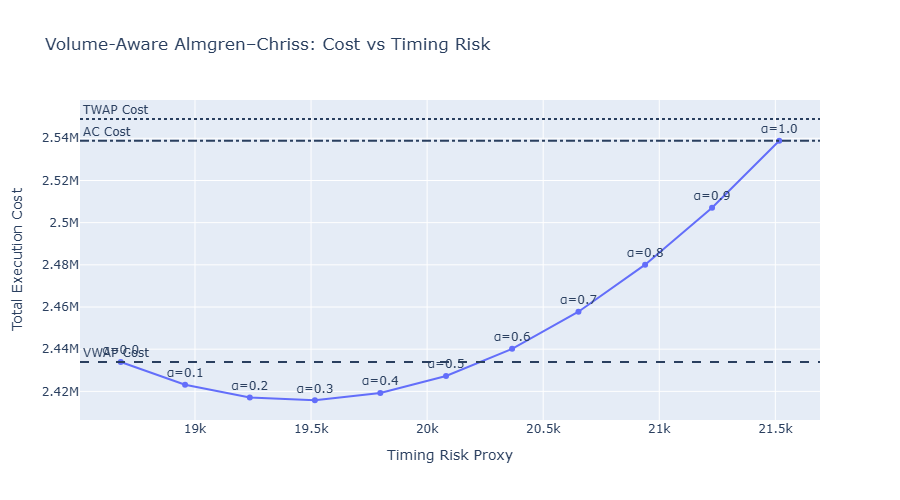

In [14]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=va_df["timing_risk_proxy"],
        y=va_df["total_cost"],
        mode="lines+markers+text",
        text=[f"α={a:.1f}" for a in va_df["alpha"]],
        textposition="top center",
        name="Volume-Aware AC"
    )
)

fig.add_hline(
    y=is_results["VWAP"]["total_cost"],
    line_dash="dash",
    annotation_text="VWAP Cost",
    annotation_position="top left"
)

fig.add_hline(
    y=is_results["TWAP"]["total_cost"],
    line_dash="dot",
    annotation_text="TWAP Cost",
    annotation_position="top left"
)

fig.add_hline(
    y=is_results["Almgren-Chriss"]["total_cost"],
    line_dash="dashdot",
    annotation_text="AC Cost",
    annotation_position="top left"
)

fig.update_layout(
    title="Volume-Aware Almgren–Chriss: Cost vs Timing Risk",
    xaxis_title="Timing Risk Proxy",
    yaxis_title="Total Execution Cost",
    height=500,
    width=900
)

fig.show()
fig.write_image("../results/plots/volume_aware_almgren_chriss_cost_vs_timing_risk.png")
display(Image(filename="../results/plots/volume_aware_almgren_chriss_cost_vs_timing_risk.png"))

### Interpretation

The volume-aware Almgren–Chriss extension produces a clear improvement over both VWAP and standard Almgren–Chriss.

- Pure VWAP ($\alpha = 0$) achieves low cost by aligning with liquidity
- Pure Almgren–Chriss ($\alpha = 1$) is more expensive under current parameterization
- Intermediate values ($\alpha \approx 0.2 - 0.3$) achieve the lowest execution cost

This indicates that:

- Liquidity information (volume) is essential for reducing execution cost
- Pure optimal control models are insufficient without market microstructure information
- A hybrid approach can outperform both baseline and optimal strategies

---

### Key Insight

> The best execution strategy is neither purely model-driven nor purely data-driven, but a combination of both.

---

### Practical Implication

In real trading systems, execution should:

- incorporate real-time liquidity information
- adapt execution schedules dynamically
- avoid rigid adherence to theoretical optimal paths

## Final Insights and Answers

This notebook evaluated execution strategies under real intraday market data, moving from theoretical simulation to a market-based setting.

---

### 1. How do execution strategies behave under real market dynamics?

TWAP remains a useful baseline because it is simple, stable, and easy to interpret.

However, VWAP improves substantially when real volume information is used. In this dataset, the real-volume VWAP schedule achieved lower execution cost than both TWAP and standard Almgren–Chriss.

This suggests that liquidity timing is critical in real execution.

---

### 2. How does real volatility affect execution risk?

Real price dynamics introduce non-simulated features such as trends, jumps, and intraday volatility clustering.

Unlike the Brownian simulation, real market paths are not purely Gaussian and can create more irregular execution outcomes.

This means execution risk is not only a function of volatility magnitude, but also of the structure of the realized price path.

---

### 3. How does market impact interact with real price movements?

Market impact systematically shifts execution prices away from the observed mid price.

In the real-data setting, execution cost is driven by two forces:

- **Market impact**, which increases execution prices as trades are placed
- **Real price movements**, which can either worsen or partially offset execution cost depending on the path

The results show that impact is not isolated from market dynamics. The final execution cost depends on both the schedule and the realized trajectory of prices.

---

### 4. Which strategy performs better under real data?

In this experiment, VWAP produced the lowest execution cost among the three classical strategies.

The observed results were:

- **VWAP**: lowest implementation shortfall
- **TWAP**: strong and stable baseline
- **Almgren–Chriss**: similar to TWAP under low $\lambda$, but highly sensitive to calibration

After introducing a volume-aware Almgren–Chriss extension, the hybrid schedule improved further.

The best result came from blending Almgren–Chriss with VWAP:

$$
n_k^{VA-AC} = \alpha n_k^{AC} + (1-\alpha)n_k^{VWAP}
$$

with intermediate values around:

$$
\alpha \approx 0.2 - 0.3
$$

This suggests that the best execution strategy was neither purely model-driven nor purely volume-driven, but a hybrid of both.

---

### 5. Does the cost-risk trade-off persist in real markets?

Yes. The cost-risk trade-off remains visible in real market data.

When varying $\lambda$ in the Almgren–Chriss model:

- Low $\lambda$ produced schedules closer to TWAP
- High $\lambda$ increased execution urgency
- Higher urgency reduced exposure but increased impact cost

However, the real-data analysis also showed that classical Almgren–Chriss may underperform if it ignores liquidity information.

This motivates the need for adaptive execution strategies that incorporate market state variables such as:

- Volume
- Volatility
- Inventory
- Time remaining

---

## Final Insight

The main finding is that real market liquidity plays a central role in execution performance.

While Almgren–Chriss provides a strong theoretical foundation, its standard form does not explicitly use volume information. VWAP benefits from real liquidity data, and the volume-aware Almgren–Chriss extension improves performance by combining both views.

> The best execution strategy is not purely theoretical or purely data-driven. It should combine optimal control with real market microstructure information.

This motivates the next stage of the project: developing adaptive execution strategies where execution decisions depend dynamically on the market state.

# <b> REFERENCES </b>

1. Almgren, R., & Chriss, N. (2000). **Optimal Execution of Portfolio Transactions.** *Journal of Risk*, 3(2), 5-39.

2. Gatheral, J. (2010). **No-Dynamic-Arbitrage and Market Impact.** *Quantitative Finance*, 10(7), 749-759.
3. Cartea, Á., Jaimungal, S., & Penalva, J. (2015). **Algorithmic and High-Frequency Trading.** Cambridge University Press.